In [2]:
import pickle
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
from scipy.stats import linregress
from fooof import FOOOF
import sys
import os
from scipy import signal
from scipy import stats

sys.path.append(os.path.abspath('..'))
from ERPtools import BANDS, process_band_states

/var/folders/pc/kr77rnc562z4p366739tyz6w0000gn/T/ipykernel_34849/1368082506.py:6: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [3]:

with open('/Users/bowmannovey/Desktop/Gangully_Proj/Decay/long_data.pkl', 'rb') as f:
    long_data = pickle.load(f)

# Flatten all days into one dict
all_long_combined = {}
for date_folder, sessions in long_data.items():
    for session, files in sessions.items():
        key = f"{date_folder}/{session}"
        all_long_combined[key] = files

print(f"Combined: {len(all_long_combined)} sessions, {sum(len(v) for v in all_long_combined.values())} files")

Combined: 18 sessions, 366 files


In [4]:
target_data = {i: {} for i in range(1, 8)}

for session_key, files_dict in all_long_combined.items():
    filtered_files_per_target = {i: {} for i in range(1, 8)}
    
    for f_key, data in files_dict.items():
        if 'TargetID' in data:
            target_array = np.array(data['TargetID']).flatten()
            for t in range(1, 8):
                if t in target_array:
                    filtered_files_per_target[t][f_key] = data
                
    for t in range(1, 8):
        if filtered_files_per_target[t]:
            target_data[t][session_key] = filtered_files_per_target[t]

print(f"Original Data: {len(all_long_combined)} sessions, {sum(len(v) for v in all_long_combined.values())} files")
for t in range(1, 8):
    print(f"Target {t} Data: {len(target_data[t])} sessions, {sum(len(v) for v in target_data[t].values())} files")

Original Data: 18 sessions, 366 files
Target 1 Data: 18 sessions, 52 files
Target 2 Data: 18 sessions, 52 files
Target 3 Data: 18 sessions, 52 files
Target 4 Data: 18 sessions, 52 files
Target 5 Data: 18 sessions, 53 files
Target 6 Data: 18 sessions, 52 files
Target 7 Data: 18 sessions, 53 files


In [1]:
xcorr_data = []
for i in range(len(target_7_data.keys())):
    session_key = list(target_7_data.keys())[i]
    file_key = list(target_7_data[session_key].keys())[0]
    data = target_7_data[session_key][file_key]

    print(f"Now plotting -> Session: {session_key} | File: {file_key}")

    # -------------------------------------------------------
    # Define a quick z-score helper
    def zscore(x):
        return (x - np.mean(x)) / (np.std(x) + 1e-10)

    # 1. Extract Neural Features
    fs = float(np.array(data['Params']['UpdateRate']).flat[0])
    features = np.array(data['SmoothedNeuralFeatures']).squeeze().T
    beta_mean = np.mean(features[512:640, :], axis=0) # Beta
    hg_mean = np.mean(features[768:, :], axis=0)      # High Gamma

    # 2. Infraslow Filter
    nyquist = 0.5 * fs
    b, a = signal.butter(4, [0.1 / nyquist, 0.4 / nyquist], btype='bandpass')
    padlen = min(len(hg_mean) - 1, 15) 
    hg_infraslow = signal.filtfilt(b, a, hg_mean, padlen=padlen)
    beta_infraslow = signal.filtfilt(b, a, beta_mean, padlen=padlen)

    # 3. Z-score normalization commands
    hg_norm = zscore(hg_mean)
    beta_norm = zscore(beta_mean)
    hg_infra_norm = zscore(hg_infraslow)
    beta_infra_norm = zscore(beta_infraslow)

    # 4. Task State for time alignment
    task_state = np.array(data['TaskState']).flatten()
    s3_idx = np.where(task_state == 3)[0]
    onset_idx = s3_idx[0] if len(s3_idx) > 0 else 0
    t_axis_neural = (np.arange(len(hg_norm)) - onset_idx) / fs

    # 5. Cross-Correlation calc
    correlation = signal.correlate(hg_norm, beta_norm, mode='full')
    correlation /= (len(hg_norm) * np.std(hg_norm) * np.std(beta_norm))
    time_lags = signal.correlation_lags(len(hg_norm), len(beta_norm), mode='full') / fs
    peak_idx = np.argmax(np.abs(correlation))
    peak_lag = time_lags[peak_idx]
    peak_corr = correlation[peak_idx]

    xcorr_data.append({
        'session': session_key,
        'file': file_key,
        'time_lags': time_lags,
        'correlation': correlation,
        'peak_lag': peak_lag,
        'peak_corr': peak_corr
    })

    # ----------------- PLOTTING STACK -----------------
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 15))
    fig.suptitle(f'Coupling Analysis: Session {session_key} | {file_key}', fontsize=16, y=0.98)

    # Panel 1: Smoothed Neural Data
    axes[0].plot(t_axis_neural, hg_norm, color='red', label='High Gamma', linewidth=2)
    axes[0].plot(t_axis_neural, beta_norm, color='blue', label='Beta', linewidth=2)
    axes[0].set_title('Smoothed Neural Data (Aligned to Target Click)')
    axes[0].set_ylabel('Normalized Amplitude (Z-score)')
    axes[0].legend(loc='upper right')

    # Panel 2: Infraslow Neural Data
    axes[1].plot(t_axis_neural, hg_infra_norm, color='red', label='High Gamma', linewidth=3)
    axes[1].plot(t_axis_neural, beta_infra_norm, color='blue', label='Beta', linewidth=3)
    axes[1].set_title('Infraslow Filtered Data (0.1 - 0.4 Hz)')
    axes[1].set_ylabel('Normalized Amplitude (Z-score)')
    axes[1].legend(loc='upper right')

    # Panel 3: Cross-Correlation
    axes[2].plot(time_lags, correlation, color='purple', linewidth=2)
    axes[2].axvline(x=peak_lag, color='red', linestyle=':', linewidth=2, 
                label=f'Peak Lag: {peak_lag:.3f}s\nPeak r: {peak_corr:.3f}')
    axes[2].set_title('Cross-Correlation (Temporal Coupling)')
    axes[2].set_xlabel('Time Lag (seconds)')
    axes[2].set_ylabel('Correlation Coefficient (r)')
    axes[2].set_xlim([-2, 2]) # Zoom in for visibility
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.show()
    # plt.savefig(f"/Users/bowmannovey/Desktop/Gangully_Proj/Decay/Kinetic_plots/XCorr_plots/{session_key.replace('/', '_')}_{file_key.replace('.mat', '')}.png")
    plt.close(fig) # Highly recommended so your notebook doesn't crash from drawing 100+ plots
print("complete")

NameError: name 'target_7_data' is not defined

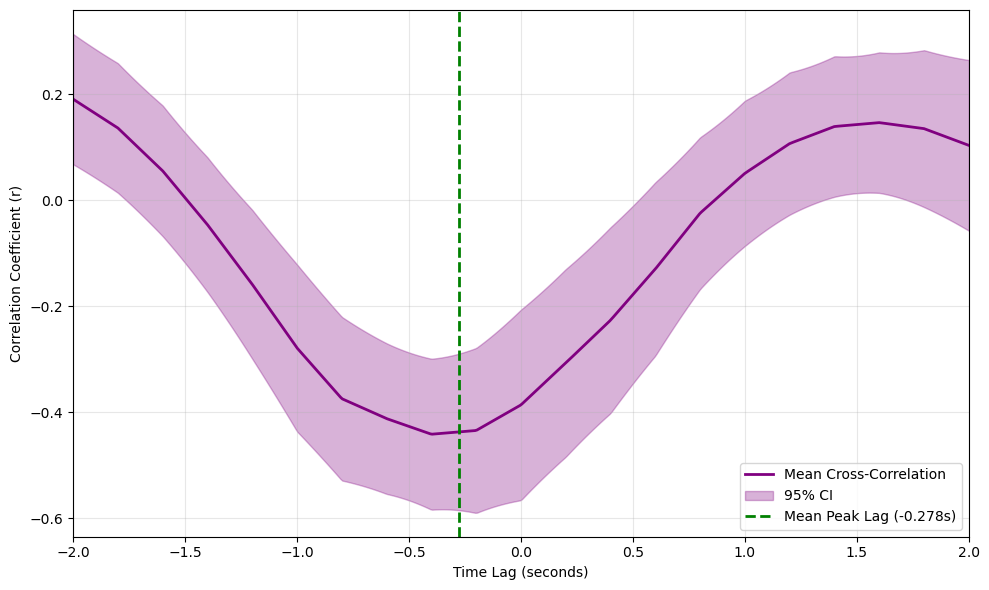

In [ ]:
# 1. Create a standardized time axis from -2.0 to 2.0 seconds
common_lags = np.linspace(-2.0, 2.0, 500)
aligned_corrs = []

# 2. Interpolate each underlying trial to match our new standardized axis
for trial in xcorr_data:
    t_lags = trial['time_lags']
    corr = trial['correlation']
    
    # np.interp needs the x-axis to be strictly increasing
    # np.interp(new_x, old_x, old_y)
    interpolated_corr = np.interp(common_lags, t_lags, corr)
    aligned_corrs.append(interpolated_corr)

# 3. Now we can safely stack them because they belong to the exact same 500 points
all_corr_arrays = np.array(aligned_corrs)
n_trials = all_corr_arrays.shape[0]

# 4. Calculate point-by-point Mean, SEM, and 95% CI
mean_corr_line = np.mean(all_corr_arrays, axis=0)
sem_corr_line = stats.sem(all_corr_arrays, axis=0)

# Calculate the Confidence Interval
ci_lower, ci_upper = stats.t.interval(0.95, df=n_trials-1, 
                                      loc=mean_corr_line, 
                                      scale=sem_corr_line)

# Setup peak lag/correlation stats for plotting
all_lags = [trial['peak_lag'] for trial in xcorr_data]
all_corrs = [trial['peak_corr'] for trial in xcorr_data]
n = len(xcorr_data)

mean_lag = np.mean(all_lags)
median_lag = np.median(all_lags)
sem_lag = stats.sem(all_lags)
ci_lag = stats.t.interval(0.95, df=n-1, loc=mean_lag, scale=sem_lag)

mean_corr = np.mean(all_corrs)
median_corrs = np.median(all_corrs)
sem_corr_val = stats.sem(all_corrs)
ci_corr_val = stats.t.interval(0.95, df=n-1, loc=mean_corr, scale=sem_corr_val)

# 5. Plotting
plt.figure(figsize=(10, 6))

# Plot the Mean Line
plt.plot(common_lags, mean_corr_line, color='purple', linewidth=2, label='Mean Cross-Correlation')

# Shade the Confidence Interval region
plt.fill_between(common_lags, ci_lower, ci_upper, color='purple', alpha=0.3, label='95% CI')

# Add vertical lines for mean and median lag
plt.axvline(x=mean_lag, color='green', linestyle='--', linewidth=2, label=f'Mean Peak Lag ({mean_lag:.3f}s)')

# Formatting
plt.xlabel('Time Lag (seconds)')
plt.ylabel('Correlation Coefficient (r)')
plt.xlim([-2.0, 2.0]) # Matches our interpolated range
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Initialize a dictionary to store cross-correlation data organized by target
# Now xcorr_data[1] has target 1's data, xcorr_data[2] has target 2's, etc.
xcorr_data = {t: [] for t in range(1, 8)}

# Define a quick z-score helper
def zscore(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-10)

for t in range(1, 8):
    current_target_data = target_data.get(t, {})
    
    for session_key, files_dict in current_target_data.items():
        # Using the first file in the session for this target
        file_key = list(files_dict.keys())[0]
        data = files_dict[file_key]

        print(f"Processing -> Target: {t} | Session: {session_key} | File: {file_key}")

        # 1. Extract Neural Features
        fs = float(np.array(data['Params']['UpdateRate']).flat[0])
        features = np.array(data['SmoothedNeuralFeatures']).squeeze().T
        beta_mean = np.mean(features[512:640, :], axis=0) # Beta
        hg_mean = np.mean(features[768:, :], axis=0)      # High Gamma

        # 2. Infraslow Filter
        nyquist = 0.5 * fs
        b, a = signal.butter(4, [0.1 / nyquist, 0.4 / nyquist], btype='bandpass')
        padlen = min(len(hg_mean) - 1, 15) 
        hg_infraslow = signal.filtfilt(b, a, hg_mean, padlen=padlen)
        beta_infraslow = signal.filtfilt(b, a, beta_mean, padlen=padlen)

        # 3. Z-score normalization commands
        hg_norm = zscore(hg_mean)
        beta_norm = zscore(beta_mean)
        hg_infra_norm = zscore(hg_infraslow)
        beta_infra_norm = zscore(beta_infraslow)

        # 4. Task State for time alignment
        task_state = np.array(data['TaskState']).flatten()
        s3_idx = np.where(task_state == 3)[0]
        onset_idx = s3_idx[0] if len(s3_idx) > 0 else 0
        t_axis_neural = (np.arange(len(hg_norm)) - onset_idx) / fs

        # 5. Cross-Correlation calc
        correlation = signal.correlate(hg_norm, beta_norm, mode='full')
        correlation /= (len(hg_norm) * np.std(hg_norm) * np.std(beta_norm))
        time_lags = signal.correlation_lags(len(hg_norm), len(beta_norm), mode='full') / fs
        peak_idx = np.argmax(np.abs(correlation))
        peak_lag = time_lags[peak_idx]
        peak_corr = correlation[peak_idx]

        xcorr_data[t].append({
            'target': t,
            'session': session_key,
            'file': file_key,
            'time_lags': time_lags,
            'correlation': correlation,
            'peak_lag': peak_lag,
            'peak_corr': peak_corr
        })

print("Cross-correlation data processing complete. Data is organized by target in 'xcorr_data'.")

Processing -> Target: 1 | Session: 20220309/111051 | File: Data0003.mat
Processing -> Target: 1 | Session: 20220309/111313 | File: Data0018.mat
Processing -> Target: 1 | Session: 20220309/132556 | File: Data0008.mat
Processing -> Target: 1 | Session: 20220309/133054 | File: Data0003.mat
Processing -> Target: 1 | Session: 20220309/140352 | File: Data0018.mat
Processing -> Target: 1 | Session: 20220316/105537 | File: Data0008.mat
Processing -> Target: 1 | Session: 20220316/132918 | File: Data0002.mat
Processing -> Target: 1 | Session: 20220325/133023 | File: Data0008.mat
Processing -> Target: 1 | Session: 20220325/133633 | File: Data0018.mat
Processing -> Target: 1 | Session: 20220427/103604 | File: Data0008.mat
Processing -> Target: 1 | Session: 20220427/104241 | File: Data0003.mat
Processing -> Target: 1 | Session: 20220427/104443 | File: Data0018.mat
Processing -> Target: 1 | Session: 20220427/104824 | File: Data0005.mat
Processing -> Target: 1 | Session: 20220427/132449 | File: Data0

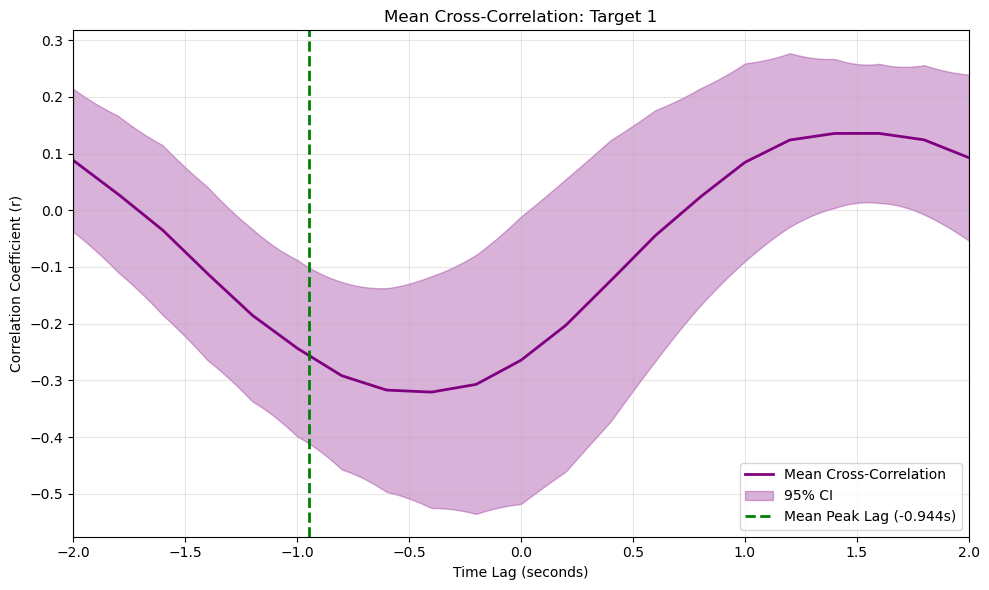

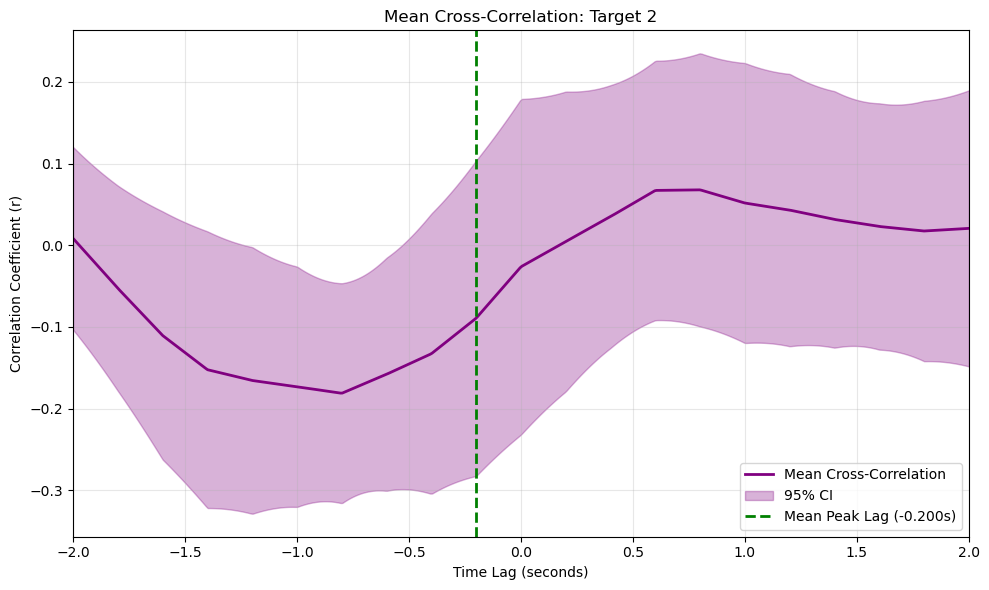

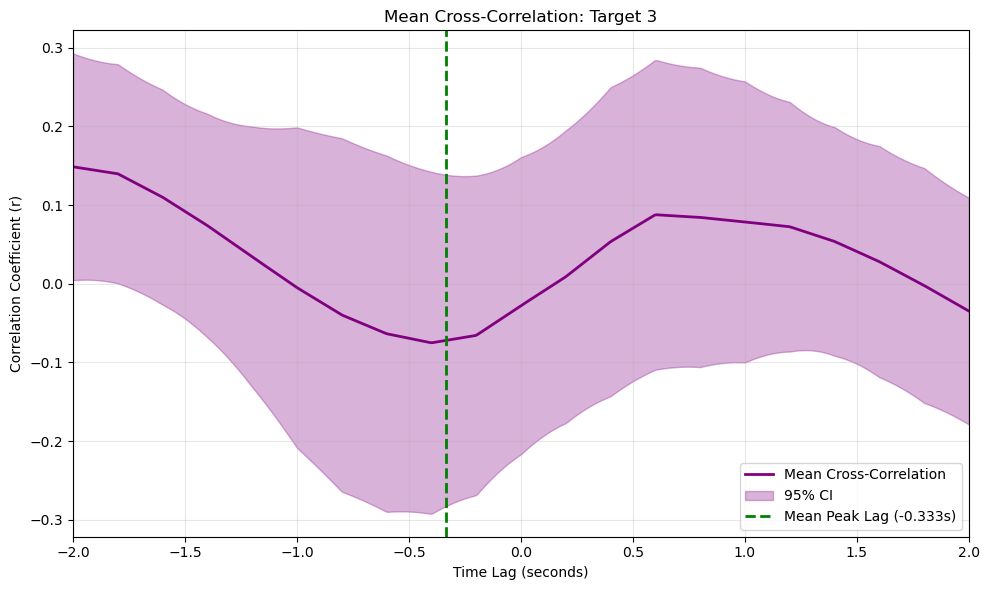

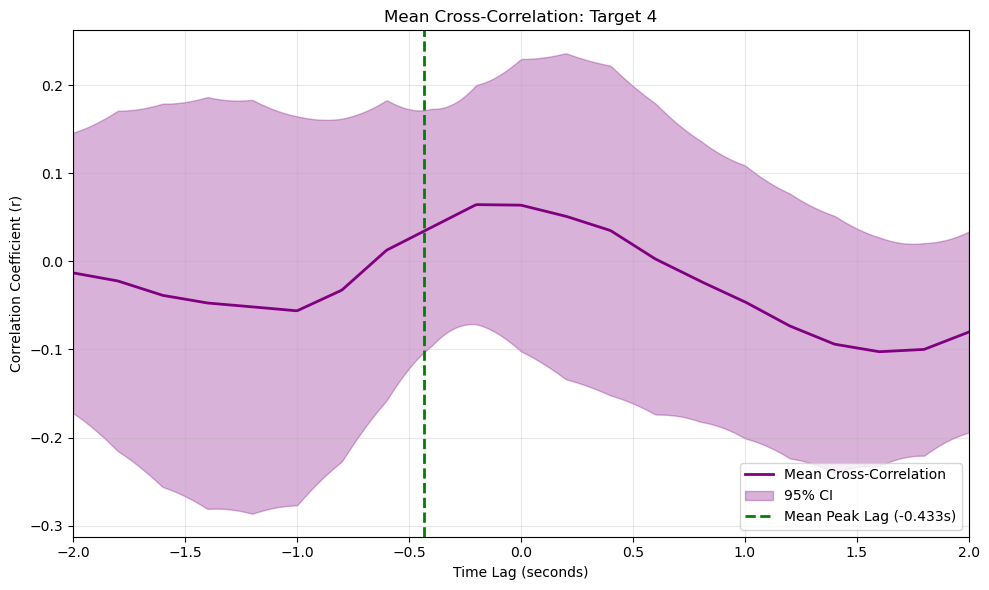

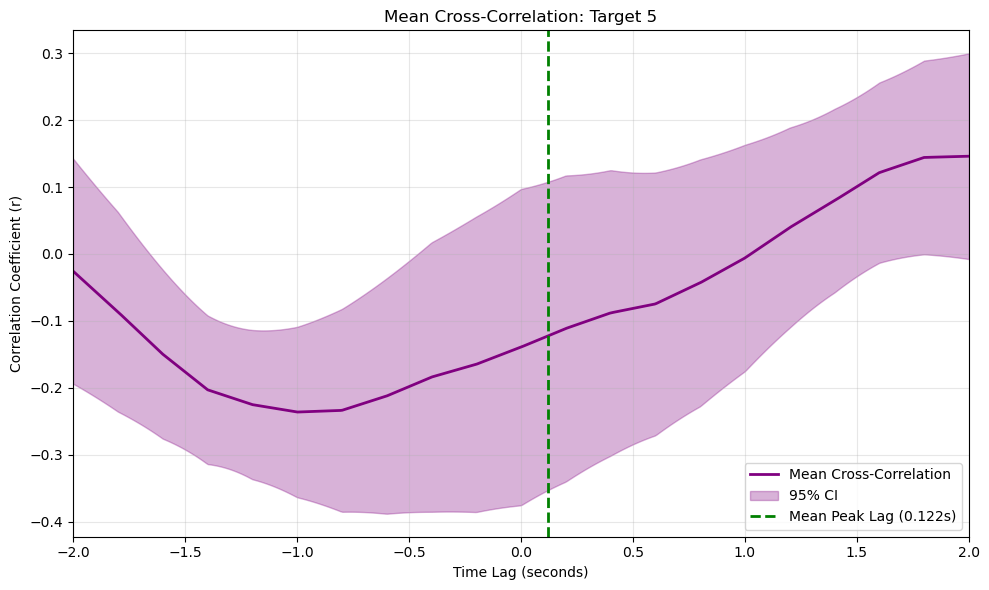

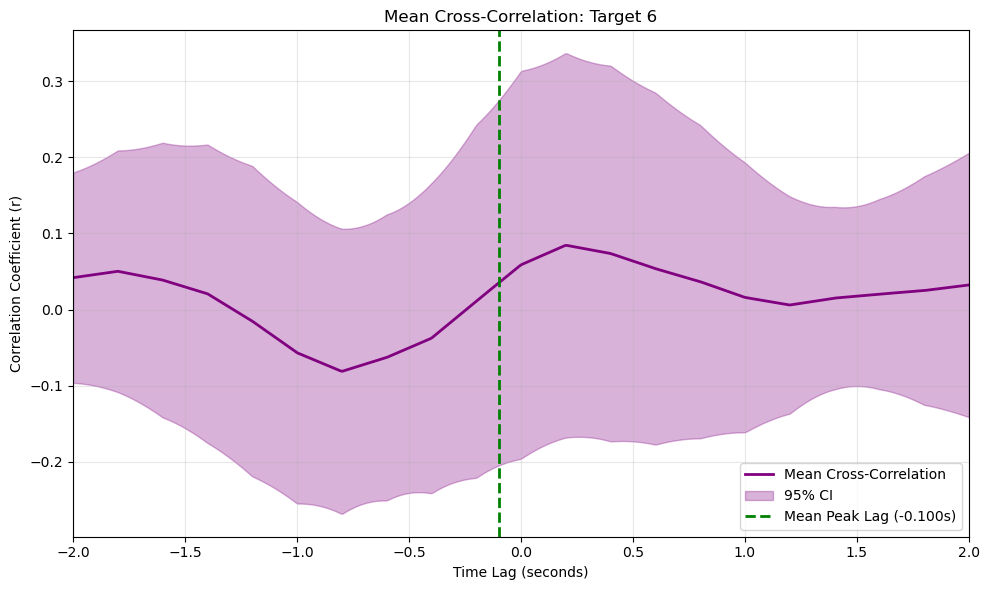

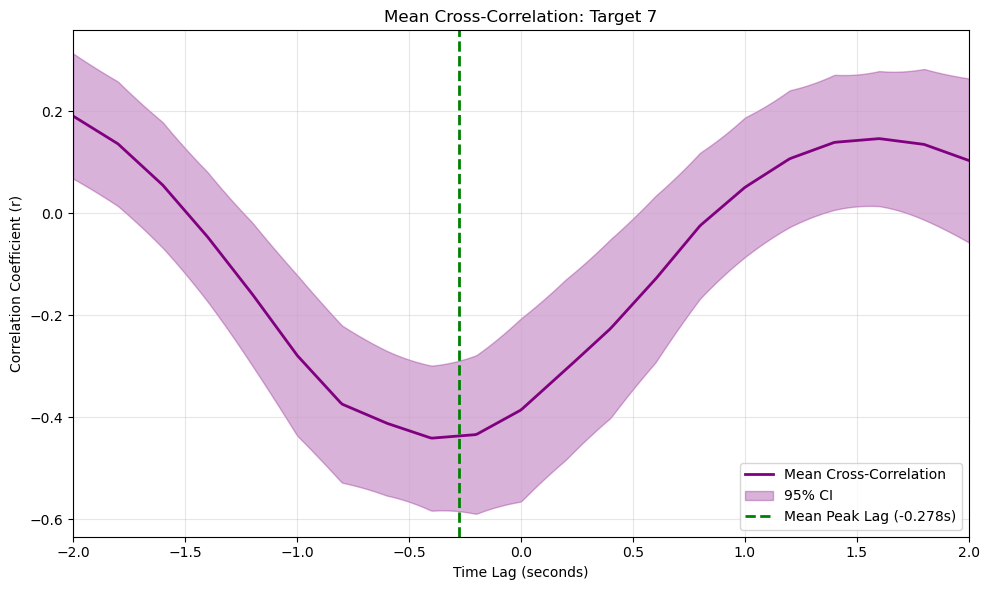

In [9]:
common_lags = np.linspace(-2.0, 2.0, 500)

for t in range(1, 8):
    target_trials = xcorr_data.get(t, [])
    
    if len(target_trials) < 2:
        print(f"Skipping Target {t} (not enough trials to compute stats)")
        continue

    aligned_corrs = []

    for trial in target_trials:
        t_lags = trial['time_lags']
        corr = trial['correlation']
        
        # np.interp needs the x-axis to be strictly increasing
        interpolated_corr = np.interp(common_lags, t_lags, corr)
        aligned_corrs.append(interpolated_corr)

    all_corr_arrays = np.array(aligned_corrs)
    n_trials = all_corr_arrays.shape[0]

    mean_corr_line = np.mean(all_corr_arrays, axis=0)
    sem_corr_line = stats.sem(all_corr_arrays, axis=0)

    # Calculate the Confidence Interval
    ci_lower, ci_upper = stats.t.interval(0.95, df=n_trials-1, 
                                          loc=mean_corr_line, 
                                          scale=sem_corr_line)

    # Setup peak lag/correlation stats for plotting
    all_lags = [trial['peak_lag'] for trial in target_trials]
    all_corrs = [trial['peak_corr'] for trial in target_trials]

    mean_lag = np.mean(all_lags)
    sem_lag = stats.sem(all_lags)

    plt.figure(figsize=(10, 6))
    plt.plot(common_lags, mean_corr_line, color='purple', linewidth=2, label='Mean Cross-Correlation')
    plt.fill_between(common_lags, ci_lower, ci_upper, color='purple', alpha=0.3, label='95% CI')
    plt.axvline(x=mean_lag, color='green', linestyle='--', linewidth=2, label=f'Mean Peak Lag ({mean_lag:.3f}s)')

    plt.title(f'Mean Cross-Correlation: Target {t}')
    plt.xlabel('Time Lag (seconds)')
    plt.ylabel('Correlation Coefficient (r)')
    plt.xlim([-2.0, 2.0]) 
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()